# CDSD 完整训练流程 - SAVAR 数据集 (v2)

**改进版本特性：**
- ✅ GPU 支持（自动检测 CUDA）
- ✅ 精度选择（float32/float64）
- ✅ 从数据集自动读取参数
- ✅ 配置系统（方便多次实验）
- ✅ 预测误差计算（MSE/SMAPE）
- ✅ 完整的可视化

## 训练步骤：
1. 环境设置和配置
2. 数据加载（自动读取参数）
3. 模型初始化
4. 训练（ALM/QPM 约束优化）
5. 评估（包含预测误差）
6. 可视化

## 1. 环境设置

In [1]:
import os
# 修复 OpenMP 库冲突问题（必须在所有其他导入之前）
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ["CDSD_DISABLE_PLOTS"] = "1"

import sys
sys.path.insert(0, 'cdsd')

import json
import time
import torch
import numpy as np

# 导入 CDSD 模块（从 cdsd-jax）
from data_loader import DataLoader
from model.tsdcd_latent import LatentTSDCD
from train_latent import TrainingLatent
from metrics import mcc_latent, shd, precision_recall, edge_errors, w_mae

print(f"✓ PyTorch {torch.__version__}")
print(f"✓ CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  GPU count: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
print("✓ All CDSD modules imported from cdsd")

✓ PyTorch 2.9.1
✓ CUDA available: False
✓ All CDSD modules imported from cdsd


## 2. 配置参数

### 使用方式：
1. **快速开始**：直接运行，使用默认配置
2. **自定义实验**：修改 `CONFIG` 字典中的参数
3. **批量实验**：修改 `exp_id` 和其他参数，重复运行

In [ ]:
# ==================== 实验配置 ====================
CONFIG = {
    # === 数据集 ===
    'data_path': "dataset/savar_N25_med-easy_seed0",
    'use_data_config': True,  # 是否从数据集自动读取 d_z, d_x, tau
    
    # === 实验输出 ===
    'exp_base_path': "cdsd_results",
    'exp_name': "savar_N25_v2",
    'exp_id': 0,  # 实验编号（exp0, exp1, exp2, ...）
    
    # === 设备和精度 ===
    'use_gpu': True,  # 自动检测并使用 GPU（如果可用）
    'use_float32': False,  # True: float32 (快但精度低), False: float64 (慢但精度高)
    
    # === 训练超参数 ===
    'max_iteration': 50000,  # 完整训练用 50000-100000，快速测试用 5000-10000
    'patience': 1000,
    'patience_post_thresh': 50,
    'batch_size': 64,
    'lr': 0.001,
    'ratio_train': 0.8,
    'ratio_valid': 0.2,
    
    # === 模型架构 ===
    'num_hidden': 0,
    'num_layers': 0,
    'num_hidden_mixing': 0,
    'num_layers_mixing': 0,
    
    # === 正则化 ===
    'reg_coeff': 1e-4,
    'coeff_kl': 1.0,
    'schedule_reg': 1000,
    'schedule_ortho': 0,
    
    # === 优化器 ===
    'optimizer': "rmsprop",
    'random_seed': 1,
    
    # === 日志频率 ===
    'valid_freq': 100,
    'print_freq': 1,
    'plot_freq': 10,
    
    # === ALM/QPM 约束优化 ===
    # 正交性约束（混合矩阵 W）
    'ortho_mu_init': 1e3,
    'ortho_mu_mult_factor': 1.2,
    'ortho_omega_gamma': 0.01,
    'ortho_omega_mu': 0.9,
    'ortho_h_threshold': 1e-4,
    'ortho_min_iter_convergence': 100,
    
    # 无环性约束（只在 instantaneous=True 时使用）
    'acyclic_mu_init': 1e1,
    'acyclic_mu_mult_factor': 2,
    'acyclic_omega_gamma': 0.01,
    'acyclic_omega_mu': 0.9,
    'acyclic_h_threshold': 1e-8,
    'acyclic_min_iter_convergence': 1000,
}

# 打印配置
print("Configuration:")
print(f"  Data: {CONFIG['data_path']}")
print(f"  Auto-read data config: {CONFIG['use_data_config']}")
print(f"  Use GPU: {CONFIG['use_gpu']} (available: {torch.cuda.is_available()})")
print(f"  Precision: {'float32' if CONFIG['use_float32'] else 'float64'}")
print(f"  Max iterations: {CONFIG['max_iteration']}")
print(f"  Experiment: {CONFIG['exp_base_path']}/{CONFIG['exp_name']}/exp{CONFIG['exp_id']}")

Configuration:
  Data: dataset/savar_N25_med-easy_seed0
  Auto-read data config: True
  Use GPU: True (available: False)
  Precision: float64
  Max iterations: 50000
  Experiment: cdsd_results/savar_N25_v2/exp0


## 3. 设置设备和精度

In [3]:
# 设置随机种子
torch.manual_seed(CONFIG['random_seed'])
np.random.seed(CONFIG['random_seed'])

# 设置设备和精度
use_gpu = CONFIG['use_gpu'] and torch.cuda.is_available()
use_float = CONFIG['use_float32']

if use_gpu:
    if use_float:
        torch.set_default_tensor_type("torch.cuda.FloatTensor")
        print("✓ Using GPU with float32")
    else:
        torch.set_default_tensor_type("torch.cuda.DoubleTensor")
        print("✓ Using GPU with float64")
    print(f"  Device: {torch.cuda.get_device_name(0)}")
else:
    if use_float:
        torch.set_default_tensor_type("torch.FloatTensor")
        print("✓ Using CPU with float32")
    else:
        torch.set_default_tensor_type("torch.DoubleTensor")
        print("✓ Using CPU with float64")

# 创建实验目录
exp_path = os.path.join(
    CONFIG['exp_base_path'], 
    CONFIG['exp_name'], 
    f"exp{CONFIG['exp_id']}"
)
os.makedirs(exp_path, exist_ok=True)
print(f"✓ Experiment directory: {exp_path}")

✓ Using CPU with float64
✓ Experiment directory: cdsd_results/savar_N25_v2/exp0


/Users/andyhou/.local/share/mamba/envs/causal_inference/lib/python3.11/site-packages/torch/__init__.py:1275: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/tensor/python_tensor.cpp:436.)
  _C._set_default_tensor_type(t)


## 4. 载入数据（自动读取参数）

In [4]:
print("Loading data...")

# 从数据集自动读取参数（如果启用）
if CONFIG['use_data_config']:
    data_params_path = os.path.join(CONFIG['data_path'], "data_params.json")
    if os.path.exists(data_params_path):
        with open(data_params_path, 'r') as f:
            data_params = json.load(f)
        
        d_x = data_params.get('d_x', 100)
        d_z = data_params.get('d_z', 25) if data_params.get('latent', True) else None
        tau = data_params.get('tau', 1)
        instantaneous = False  # SAVAR 固定使用 False
        
        print(f"✓ Auto-read from data_params.json:")
        print(f"  d_x = {d_x}")
        print(f"  d_z = {d_z}")
        print(f"  tau = {tau}")
    else:
        print("⚠ data_params.json not found, using defaults")
        d_x = 100
        d_z = 25
        tau = 1
        instantaneous = False
else:
    # 手动指定参数
    d_x = 100
    d_z = 25
    tau = 1
    instantaneous = False
    print("Using manual configuration")

# 加载数据
data_loader = DataLoader(
    ratio_train=CONFIG['ratio_train'],
    ratio_valid=CONFIG['ratio_valid'],
    data_path=CONFIG['data_path'],
    data_format="numpy",
    latent=True,
    no_gt=False,
    debug_gt_w=False,
    instantaneous=instantaneous,
    tau=tau
)

print(f"\n✓ Data loaded successfully!")
print(f"  X shape: {data_loader.x.shape}")
print(f"  Z shape: {data_loader.z.shape}")
print(f"  Train samples: {data_loader.n_train}")
print(f"  Valid samples: {data_loader.n_valid}")
print(f"  GT graph shape: {data_loader.gt_graph.shape}")
print(f"  GT W shape: {data_loader.gt_w.shape}")

Loading data...
✓ Auto-read from data_params.json:
  d_x = 100
  d_z = 25
  tau = 1

✓ Data loaded successfully!
  X shape: (1, 2000, 1, 100)
  Z shape: (1, 2000, 1, 25)
  Train samples: 1580
  Valid samples: 400
  GT graph shape: (1, 25, 25)
  GT W shape: (1, 100, 25)


## 5. 初始化模型

In [5]:
print("Initializing model...")

d = data_loader.x.shape[2]
num_input = d * tau * 1  # tau_neigh = 0

model = LatentTSDCD(
    num_layers=CONFIG['num_layers'],
    num_hidden=CONFIG['num_hidden'],
    num_input=num_input,
    num_output=2,
    num_layers_mixing=CONFIG['num_layers_mixing'],
    num_hidden_mixing=CONFIG['num_hidden_mixing'],
    coeff_kl=CONFIG['coeff_kl'],
    d=d,
    distr_z0="gaussian",
    distr_encoder="gaussian",
    distr_transition="gaussian",
    distr_decoder="gaussian",
    d_x=d_x,
    d_z=d_z,
    tau=tau,
    instantaneous=instantaneous,
    nonlinear_mixing=False,
    hard_gumbel=True,
    no_gt=False,
    debug_gt_graph=False,
    debug_gt_z=False,
    debug_gt_w=False,
    gt_w=data_loader.gt_w,
    gt_graph=data_loader.gt_graph,
    tied_w=False
)

print(f"\n✓ Model initialized!")
print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")
if use_gpu:
    print(f"  Model on device: {next(model.parameters()).device}")

Initializing model...

✓ Model initialized!
  Total parameters: 6,425


## 6. 准备训练器

In [6]:
print("Setting up trainer...")

# 创建超参数对象
class HParams:
    def __init__(self, **kwargs):
        self.__dict__.update(kwargs)

hp = HParams(
    # 数据相关
    latent=True,
    no_gt=False,
    debug_gt_z=False,
    d_z=d_z,
    d_x=d_x,
    tau=tau,
    instantaneous=instantaneous,
    no_w_constraint=False,
    
    # 训练相关
    batch_size=CONFIG['batch_size'],
    max_iteration=CONFIG['max_iteration'],
    patience=CONFIG['patience'],
    patience_post_thresh=CONFIG['patience_post_thresh'],
    
    # 优化器
    optimizer=CONFIG['optimizer'],
    lr=CONFIG['lr'],
    
    # 正则化
    reg_coeff=CONFIG['reg_coeff'],
    schedule_reg=CONFIG['schedule_reg'],
    schedule_ortho=CONFIG['schedule_ortho'],
    
    # ALM/QPM - 正交性约束
    ortho_mu_init=CONFIG['ortho_mu_init'],
    ortho_mu_mult_factor=CONFIG['ortho_mu_mult_factor'],
    ortho_omega_gamma=CONFIG['ortho_omega_gamma'],
    ortho_omega_mu=CONFIG['ortho_omega_mu'],
    ortho_h_threshold=CONFIG['ortho_h_threshold'],
    ortho_min_iter_convergence=CONFIG['ortho_min_iter_convergence'],
    
    # ALM/QPM - 无环性约束
    acyclic_mu_init=CONFIG['acyclic_mu_init'],
    acyclic_mu_mult_factor=CONFIG['acyclic_mu_mult_factor'],
    acyclic_omega_gamma=CONFIG['acyclic_omega_gamma'],
    acyclic_omega_mu=CONFIG['acyclic_omega_mu'],
    acyclic_h_threshold=CONFIG['acyclic_h_threshold'],
    acyclic_min_iter_convergence=CONFIG['acyclic_min_iter_convergence'],
    
    # 日志
    valid_freq=CONFIG['valid_freq'],
    print_freq=CONFIG['print_freq'],
    plot_freq=CONFIG['plot_freq'],
    plot_through_time=False,
    exp_path=exp_path,
)

# 载入 best_metrics
with open(os.path.join(CONFIG['data_path'], 'best_metrics.json'), 'r') as f:
    best_metrics = json.load(f)

# 创建训练器
trainer = TrainingLatent(model, data_loader, hp, best_metrics)

print("\n✓ Trainer ready!")
print(f"  Using TrainingLatent with ALM/QPM constraints")

Setting up trainer...
Plotting disabled: CDSD_DISABLE_PLOTS is set

✓ Trainer ready!
  Using TrainingLatent with ALM/QPM constraints


## 7. 开始训练

完整的训练流程包括：
1. **ALM/QPM 优化阶段**：优化正交性约束
2. **继续训练阶段**：直到验证损失稳定
3. **阈值化阶段**：将邻接矩阵二值化
4. **微调阶段**：在固定图结构下微调参数

In [7]:
print("\n" + "="*70)
print("Starting Training with ALM/QPM Constraint Optimization")
print("="*70)
print(f"Max iterations: {CONFIG['max_iteration']}")
print(f"Validation every {CONFIG['valid_freq']} iterations")
print(f"Patience: {CONFIG['patience']}")
print(f"Device: {'GPU' if use_gpu else 'CPU'}")
print("="*70 + "\n")

t0 = time.time()

# 完整的训练流程
valid_loss = trainer.train_with_QPM()

training_time = time.time() - t0

print("\n" + "="*70)
print(f"✓ Training completed!")
print(f"  Total time: {training_time:.2f}s ({training_time/60:.2f} minutes)")
print(f"  Iterations: {trainer.iteration}")
print(f"  Converged: {trainer.converged}")
print(f"  Thresholded: {trainer.thresholded}")
print("="*70)


Starting Training with ALM/QPM Constraint Optimization
Max iterations: 50000
Validation every 100 iterations
Patience: 1000
Device: CPU

Iteration #100
Converged: False
ELBO: -259.9220
Recons: -126.3698
KL: 133.5523
Sparsity_reg: 0.0e+00
ortho cons: -2.5e-03
ortho mu: 1000.0
-------------------------------
valid_ELBO: -262.1174
patience: 1000
Iteration #200
Converged: False
ELBO: -219.9701
Recons: -116.8869
KL: 103.0832
Sparsity_reg: 0.0e+00
ortho cons: -1.5e-03
ortho mu: 1000.0
-------------------------------
valid_ELBO: -223.3595
patience: 1000
Iteration #300
Converged: False
ELBO: -203.3192
Recons: -121.0237
KL: 82.2955
Sparsity_reg: 0.0e+00
ortho cons: 9.9e-05
ortho mu: 1000.0
-------------------------------
valid_ELBO: -195.3393
patience: 1000
Iteration #400
Converged: False
ELBO: -181.4281
Recons: -115.6483
KL: 65.7798
Sparsity_reg: 0.0e+00
ortho cons: 3.6e-03
ortho mu: 1000.0
-------------------------------
valid_ELBO: -172.8058
patience: 1000
Iteration #500
Converged: False
EL

## 8. 评估结果（包含因果结构 + 预测误差）

In [8]:
adj_prob = np.array(trainer.model.get_adj())
print("adj prob stats: min", adj_prob.min(), "max", adj_prob.max(), "mean", adj_prob.mean())

w_dec = trainer.model.autoencoder.get_w_decoder().detach().cpu().numpy()
print("W decoder stats: min", w_dec.min(), "max", w_dec.max(), "mean", w_dec.mean())

adj prob stats: min 0.0 max 1.0 mean 0.08
W decoder stats: min 0.0 max 0.7079275207347869 mean 0.015256224488978643


/var/folders/93/6c2klk653cb959ghjf6pk9pm0000gn/T/ipykernel_37587/3396625088.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  adj_prob = np.array(trainer.model.get_adj())


In [9]:
print("\nEvaluating results...")

# 获取学习的图
gt_graph = trainer.gt_dag
learned_graph = trainer.model.get_adj().detach().cpu().numpy().reshape(
    gt_graph.shape[0], gt_graph.shape[1], -1
)

# 计算 MCC 和潜变量对应
score, cc_program_perm, assignments, z, z_hat, _ = mcc_latent(trainer.model, trainer.data)

# 根据学习到的潜变量排列重新排列 ground truth
permutation = np.zeros((gt_graph.shape[1], gt_graph.shape[1]))
permutation[np.arange(gt_graph.shape[1]), assignments[1]] = 1
gt_graph_permuted = permutation.T @ gt_graph @ permutation

# 计算所有评估指标
metrics = {
    'mcc': score,
    'w_mae': w_mae(
        trainer.model.autoencoder.get_w_decoder().detach().cpu().numpy()[:, :, assignments[1]], 
        data_loader.gt_w
    ),
    'shd': shd(learned_graph, gt_graph_permuted),
    'training_time': training_time,
    'n_iterations': trainer.iteration,
    'converged': trainer.converged,
    'thresholded': trainer.thresholded,
}

prec, rec = precision_recall(learned_graph, gt_graph_permuted)
metrics['precision'] = prec
metrics['recall'] = rec

errors = edge_errors(learned_graph, gt_graph_permuted)
metrics.update(errors)
metrics.update(valid_loss)

# 添加边统计量
metrics['n_edge_gt_graph'] = np.sum(gt_graph_permuted)
metrics['n_edge_learned_graph'] = np.sum(learned_graph)

print("\n" + "="*70)
print("Causal Structure Evaluation")
print("="*70)
print(f"MCC (latent recovery):  {metrics['mcc']:.4f}")
print(f"SHD (graph distance):   {metrics['shd']:.1f}")
print(f"Precision:              {metrics['precision']:.4f}")
print(f"Recall:                 {metrics['recall']:.4f}")
print(f"W MAE:                  {metrics['w_mae']:.4f}")
print(f"\nTrue Positives:  {metrics['tp']}")
print(f"False Positives: {metrics['fp']}")
print(f"True Negatives:  {metrics['tn']}")
print(f"False Negatives: {metrics['fn']}")
print(f"\nGT edges:      {metrics['n_edge_gt_graph']:.0f}")
print(f"Learned edges: {metrics['n_edge_learned_graph']:.0f}")
print("="*70)


Evaluating results...

Causal Structure Evaluation
MCC (latent recovery):  0.9620
SHD (graph distance):   4.0
Precision:              0.9600
Recall:                 0.9600
W MAE:                  0.0053

True Positives:  48.0
False Positives: 2.0
True Negatives:  573.0
False Negatives: 2.0

GT edges:      50
Learned edges: 50


## 8.5. 计算预测误差（MSE 和 SMAPE）

评估模型的**时间序列预测能力**（预测下一时刻的观测值）

In [10]:
def calculate_prediction_error(trainer, valid=False, max_samples=1000):
    """
    计算 X_{t+1} 和 X_hat_{t+1} 之间的 MSE 和 SMAPE

    MSE: Mean Squared Error
    SMAPE: Symmetric Mean Absolute Percentage Error
    """
    if not valid:
        bs = min(trainer.data.n_train, max_samples)
        x, y, _ = trainer.data.sample(bs, valid=False)
    else:
        bs = min(trainer.data.n_valid, max_samples)
        x, y, _ = trainer.data.sample(bs, valid=True)

    # 获取预测
    y, y_pred = trainer.model.predict(x, y)

    with torch.no_grad():
        # MSE: 0.5 * (y - y_pred)^2 的平均
        mse = torch.mean(torch.sum(0.5 * (y - y_pred) ** 2, dim=2))

        # SMAPE: 2 * |y - y_pred| / (|y| + |y_pred|) 的平均
        smape = torch.mean(torch.sum(
            2 * (y - y_pred).abs() / (y.abs() + y_pred.abs() + 1e-8),
            dim=2
        ))

    return mse.item(), smape.item()

print("\n" + "="*70)
print("Prediction Error Evaluation")
print("="*70)

# 训练集预测误差
train_mse, train_smape = calculate_prediction_error(trainer, valid=False)
print(f"Train MSE:   {train_mse:.6f}")
print(f"Train SMAPE: {train_smape:.6f}")

# 验证集预测误差
val_mse, val_smape = calculate_prediction_error(trainer, valid=True)
print(f"Val MSE:     {val_mse:.6f}")
print(f"Val SMAPE:   {val_smape:.6f}")
print("="*70)

# 添加到 metrics 字典
metrics['train_mse'] = train_mse
metrics['train_smape'] = train_smape
metrics['val_mse'] = val_mse
metrics['val_smape'] = val_smape

print("\n✓ Prediction errors calculated")


Prediction Error Evaluation
Train MSE:   26.854683
Train SMAPE: 148.325115
Val MSE:     26.993433
Val SMAPE:   149.546364

✓ Prediction errors calculated


## 8.6. 保存结果

In [11]:
# 保存完整的评估结果（包含预测误差）
with open(os.path.join(exp_path, "results.json"), "w") as f:
    json.dump(metrics, f, indent=4)

# 保存配置参数
config_to_save = CONFIG.copy()
config_to_save['d_z'] = d_z
config_to_save['d_x'] = d_x
config_to_save['tau'] = tau
config_to_save['instantaneous'] = instantaneous
config_to_save['device'] = 'cuda' if use_gpu else 'cpu'
config_to_save['dtype'] = 'float32' if use_float else 'float64'

with open(os.path.join(exp_path, "config.json"), "w") as f:
    json.dump(config_to_save, f, indent=4)

print(f"\n✓ Results and config saved to: {exp_path}/")
print(f"  - results.json (评估指标)")
print(f"  - config.json (完整配置)")


✓ Results and config saved to: cdsd_results/savar_N25_v2/exp0/
  - results.json (评估指标)
  - config.json (完整配置)


## 9. 可视化：训练曲线

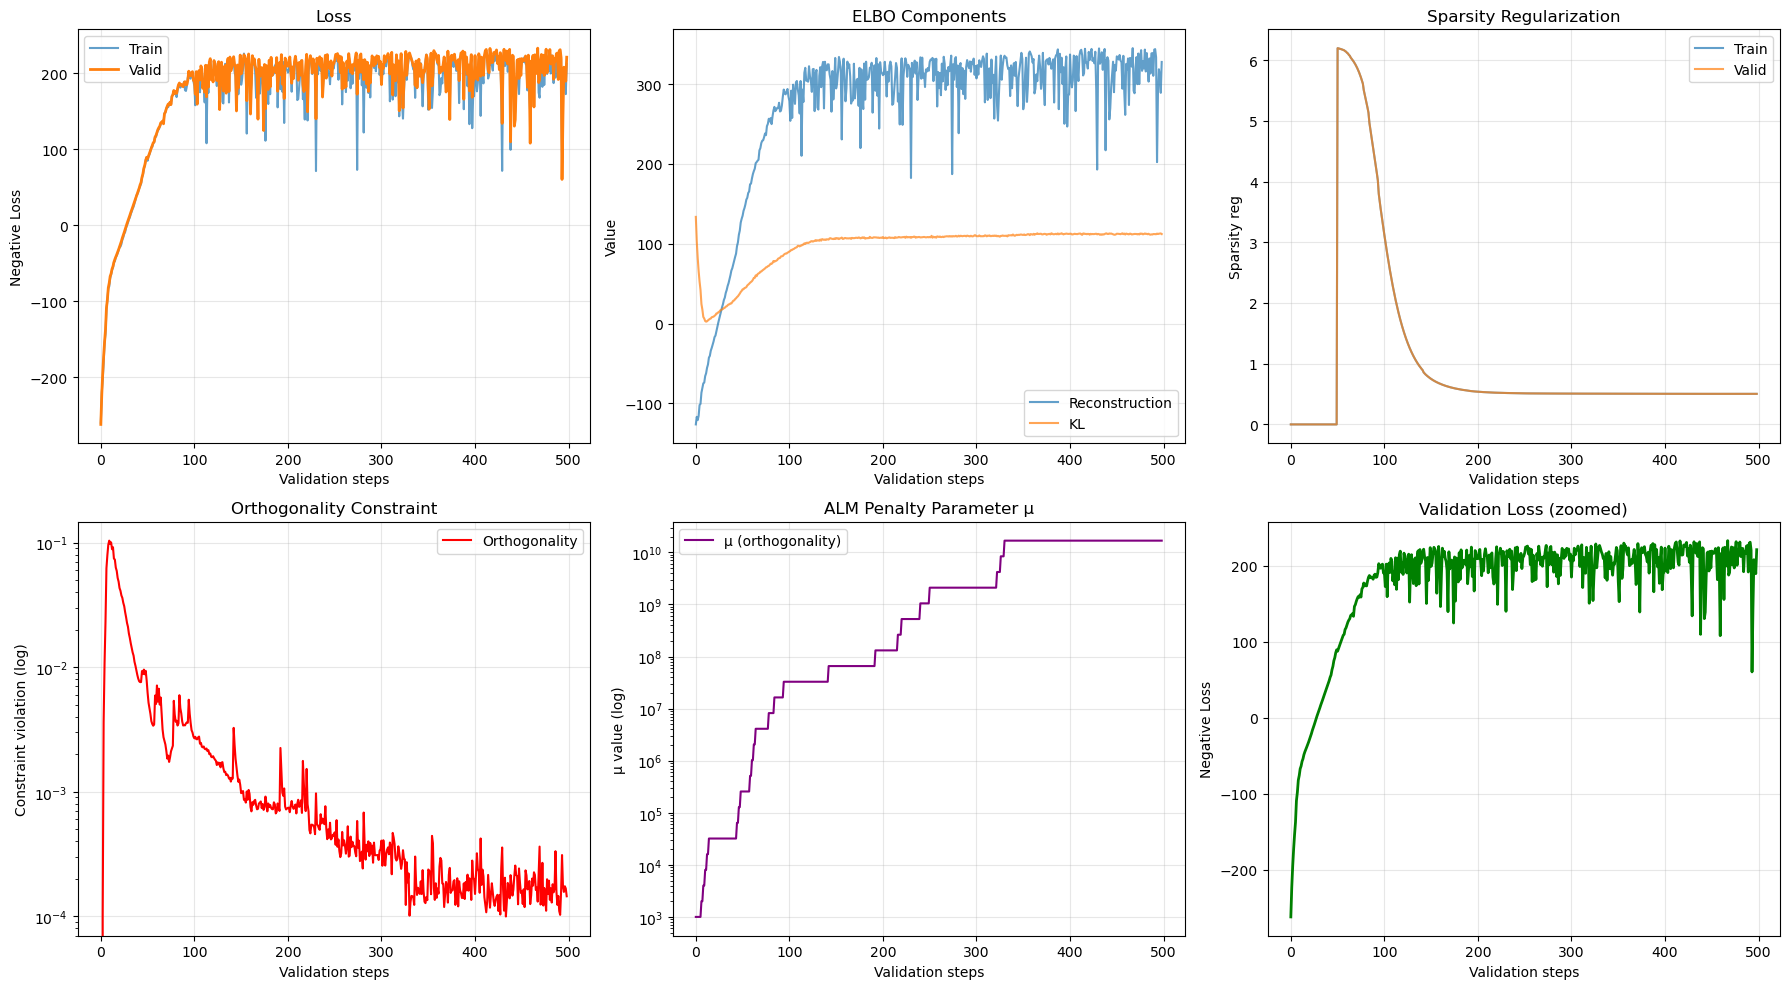

✓ Training curves saved to cdsd_results/savar_N25_v2/exp0/training_curves.png


In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Loss
axes[0, 0].plot(trainer.train_loss_list, label='Train', alpha=0.7)
axes[0, 0].plot(trainer.valid_loss_list, label='Valid', linewidth=2)
axes[0, 0].set_xlabel('Validation steps')
axes[0, 0].set_ylabel('Negative Loss')
axes[0, 0].set_title('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# ELBO components
axes[0, 1].plot(trainer.train_recons_list, label='Reconstruction', alpha=0.7)
axes[0, 1].plot(trainer.train_kl_list, label='KL', alpha=0.7)
axes[0, 1].set_xlabel('Validation steps')
axes[0, 1].set_ylabel('Value')
axes[0, 1].set_title('ELBO Components')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Sparsity regularization
axes[0, 2].plot(trainer.train_sparsity_reg_list, label='Train', alpha=0.7)
axes[0, 2].plot(trainer.valid_sparsity_reg_list, label='Valid', alpha=0.7)
axes[0, 2].set_xlabel('Validation steps')
axes[0, 2].set_ylabel('Sparsity reg')
axes[0, 2].set_title('Sparsity Regularization')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Orthogonality constraint violation
axes[1, 0].semilogy([torch.sum(c).item() for c in trainer.train_ortho_vector_cons_list], 
                     label='Orthogonality', color='red')
axes[1, 0].set_xlabel('Validation steps')
axes[1, 0].set_ylabel('Constraint violation (log)')
axes[1, 0].set_title('Orthogonality Constraint')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Mu (penalty parameter)
axes[1, 1].semilogy(trainer.mu_ortho_list, label='μ (orthogonality)', color='purple')
axes[1, 1].set_xlabel('Validation steps')
axes[1, 1].set_ylabel('μ value (log)')
axes[1, 1].set_title('ALM Penalty Parameter μ')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Valid loss zoomed
axes[1, 2].plot(trainer.valid_loss_list, linewidth=2, color='green')
axes[1, 2].set_xlabel('Validation steps')
axes[1, 2].set_ylabel('Negative Loss')
axes[1, 2].set_title('Validation Loss (zoomed)')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(exp_path, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Training curves saved to {exp_path}/training_curves.png")

## 10. 可视化：学习的图 vs Ground Truth

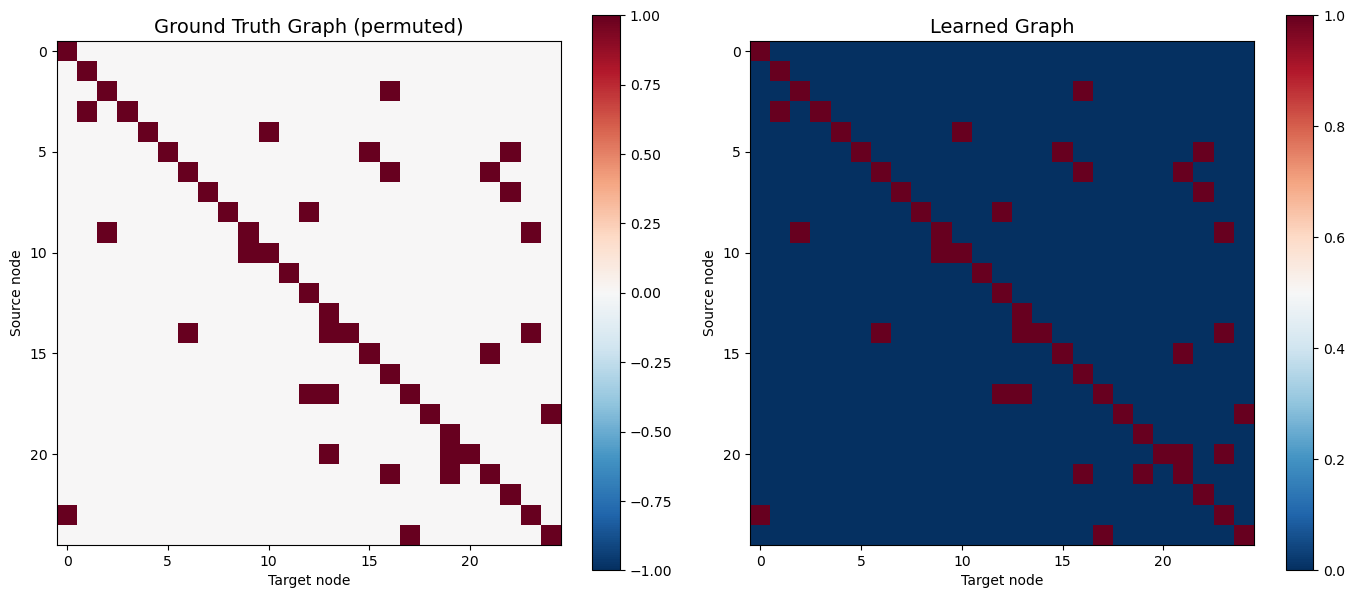

✓ Graph comparison saved to cdsd_results/savar_N25_v2/exp0/learned_vs_gt_graph.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Ground Truth (permuted)
im1 = axes[0].imshow(gt_graph_permuted[0], cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_title('Ground Truth Graph (permuted)', fontsize=14)
axes[0].set_xlabel('Target node')
axes[0].set_ylabel('Source node')
plt.colorbar(im1, ax=axes[0])

# Learned
im2 = axes[1].imshow(learned_graph[0], cmap='RdBu_r', vmin=0, vmax=1)
axes[1].set_title('Learned Graph', fontsize=14)
axes[1].set_xlabel('Target node')
axes[1].set_ylabel('Source node')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.savefig(os.path.join(exp_path, 'learned_vs_gt_graph.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Graph comparison saved to {exp_path}/learned_vs_gt_graph.png")

## 11. 可视化：混合矩阵 W

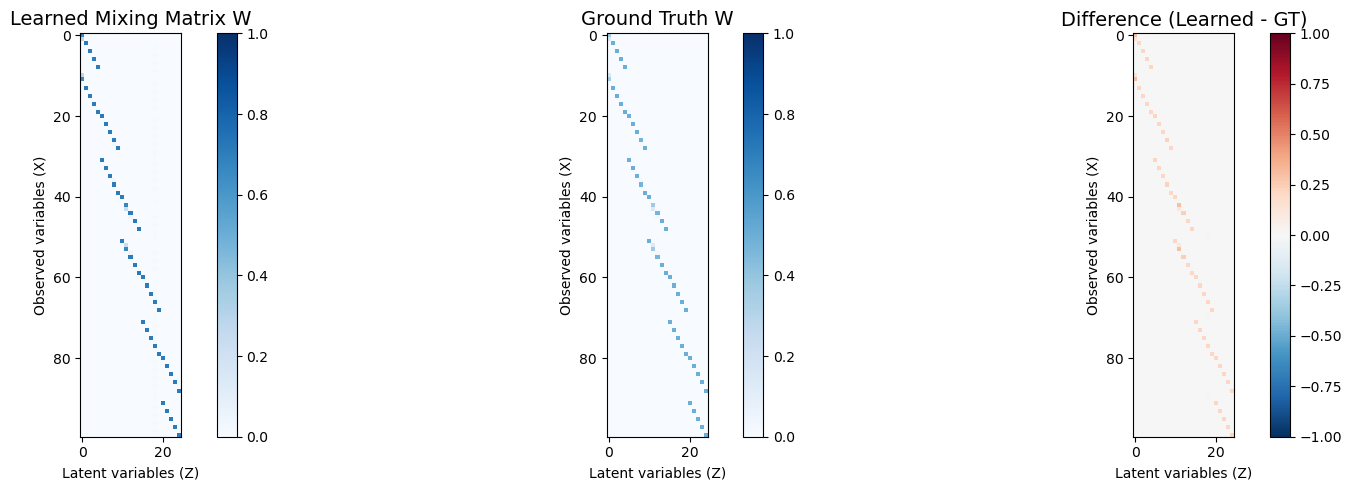

✓ Mixing matrix W saved to cdsd_results/savar_N25_v2/exp0/mixing_matrix_w.png


In [14]:
# 获取学习的混合矩阵
learned_w = trainer.model.autoencoder.get_w_decoder().detach().cpu().numpy()[:, :, assignments[1]]
gt_w = data_loader.gt_w

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Learned W
im1 = axes[0].imshow(learned_w[0], cmap='Blues', vmin=0, vmax=1)
axes[0].set_title('Learned Mixing Matrix W', fontsize=14)
axes[0].set_xlabel('Latent variables (Z)')
axes[0].set_ylabel('Observed variables (X)')
plt.colorbar(im1, ax=axes[0])

# Ground Truth W
im2 = axes[1].imshow(gt_w[0], cmap='Blues', vmin=0, vmax=1)
axes[1].set_title('Ground Truth W', fontsize=14)
axes[1].set_xlabel('Latent variables (Z)')
axes[1].set_ylabel('Observed variables (X)')
plt.colorbar(im2, ax=axes[1])

# Difference
diff_w = learned_w[0] - gt_w[0]
im3 = axes[2].imshow(diff_w, cmap='RdBu_r', vmin=-1, vmax=1)
axes[2].set_title('Difference (Learned - GT)', fontsize=14)
axes[2].set_xlabel('Latent variables (Z)')
axes[2].set_ylabel('Observed variables (X)')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.savefig(os.path.join(exp_path, 'mixing_matrix_w.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Mixing matrix W saved to {exp_path}/mixing_matrix_w.png")

## 12. 完整结果总结

In [15]:
print("\n" + "="*70)
print("COMPLETE RESULTS SUMMARY")
print("="*70)

print("\n📊 Causal Structure Discovery:")
print(f"  MCC (latent recovery):  {metrics['mcc']:.4f}")
print(f"  SHD (graph distance):   {metrics['shd']:.1f}")
print(f"  Precision:              {metrics['precision']:.4f}")
print(f"  Recall:                 {metrics['recall']:.4f}")
print(f"  W MAE:                  {metrics['w_mae']:.4f}")

print("\n📈 Prediction Performance:")
print(f"  Train MSE:   {metrics['train_mse']:.6f}")
print(f"  Train SMAPE: {metrics['train_smape']:.6f}")
print(f"  Val MSE:     {metrics['val_mse']:.6f}")
print(f"  Val SMAPE:   {metrics['val_smape']:.6f}")

print("\n⚙️ Training Info:")
print(f"  Time:       {training_time:.2f}s ({training_time/60:.2f} min)")
print(f"  Iterations: {trainer.iteration}")
print(f"  Device:     {'GPU' if use_gpu else 'CPU'}")
print(f"  Precision:  {'float32' if use_float else 'float64'}")

print("\n💾 Saved Files:")
print(f"  {exp_path}/")
print(f"    - results.json (完整评估指标)")
print(f"    - config.json (实验配置)")
print(f"    - training_curves.png")
print(f"    - learned_vs_gt_graph.png")
print(f"    - mixing_matrix_w.png")

print("\n" + "="*70)
print("✓ ALL DONE!")
print("="*70)


COMPLETE RESULTS SUMMARY

📊 Causal Structure Discovery:
  MCC (latent recovery):  0.9620
  SHD (graph distance):   4.0
  Precision:              0.9600
  Recall:                 0.9600
  W MAE:                  0.0053

📈 Prediction Performance:
  Train MSE:   26.854683
  Train SMAPE: 148.325115
  Val MSE:     26.993433
  Val SMAPE:   149.546364

⚙️ Training Info:
  Time:       450.95s (7.52 min)
  Iterations: 50000
  Device:     CPU
  Precision:  float64

💾 Saved Files:
  cdsd_results/savar_N25_v2/exp0/
    - results.json (完整评估指标)
    - config.json (实验配置)
    - training_curves.png
    - learned_vs_gt_graph.png
    - mixing_matrix_w.png

✓ ALL DONE!


In [16]:
from cdsd.plot_savar import Plotter

print("\n" + "="*70)
print("Generating plots with Plotter...")
print("="*70)

plotter = Plotter()
plotter.plot(trainer, save=True)

print("\n✓ Additional plots generated by Plotter:")
print(f"  {exp_path}/training_loss.png")
print(f"  {exp_path}/penalties.png")
print(f"  {exp_path}/adjacency_transition.png")
print(f"  {exp_path}/adjacency_decoder_w.png")
print(f"  {exp_path}/mcc.png")
print("="*70)


Generating plots with Plotter...

✓ Additional plots generated by Plotter:
  cdsd_results/savar_N25_v2/exp0/training_loss.png
  cdsd_results/savar_N25_v2/exp0/penalties.png
  cdsd_results/savar_N25_v2/exp0/adjacency_transition.png
  cdsd_results/savar_N25_v2/exp0/adjacency_decoder_w.png
  cdsd_results/savar_N25_v2/exp0/mcc.png


---

## 🎯 下一步：如何进行多次实验

### 方法 1：修改 CONFIG 字典
在 **Cell 2** 中修改 `CONFIG` 字典，例如：
```python
CONFIG = {
    'exp_id': 1,  # 改为 1, 2, 3, ...
    'max_iteration': 50000,  # 修改训练迭代次数
    'lr': 0.0001,  # 修改学习率
    # ...
}
```
然后重新运行所有 cells。

### 方法 2：使用不同数据集
```python
CONFIG = {
    'data_path': "cdsd/dataset/savar_N25_hard_seed1",  # 不同数据集
    'exp_name': "savar_N25_hard",  # 不同实验名称
    # ...
}
```

### 方法 3：批量实验脚本
创建一个 Python 脚本自动运行多个配置（类似原来的 main.py）。

---

## 📝 版本历史

**v2 改进 (2025-12-02)**：
- ✅ 添加 GPU 支持（自动检测）
- ✅ 精度选择（float32/float64）
- ✅ 从数据集自动读取参数（d_z, d_x, tau）
- ✅ 配置系统（CONFIG 字典）
- ✅ 预测误差计算（MSE/SMAPE）
- ✅ 边统计量保存
- ✅ 实验编号支持（exp0, exp1, ...）

**v1 (原版)**：
- 基础训练和可视化